In [ ]:
!git clone https://github.com/EnergyBasedFlowClassifier/EFC-package.git
%cd EFC-package
!pip install -r requirements.txt
!pip install --no-build-isolation .
%cd /content/EFC-package
!python setup.py build_ext --inplace
!pip install --no-build-isolation -e .

from google.colab import drive
import os
drive.mount("/content/drive", force_remount = True)
path = "/content/drive/My Drive/TCC/Dataset-final"
if os.path.isdir(path):
  !ls "{path}"

Cloning into 'EFC-package'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 270 (delta 12), reused 15 (delta 7), pack-reused 243 (from 1)
Receiving objects: 100% (270/270), 982.43 KiB | 14.03 MiB/s, done.
Resolving deltas: 100% (139/139), done.
/content/EFC-package
Processing /content/EFC-package
  Preparing metadata (setup.py) ... done
  Created wheel for efc: filename=efc-0.1.0-cp312-cp312-linux_x86_64.whl size=544839 sha256=a091cf6c7e3c831e6fa3d39070ebb9185d12318c87d9a6ac8052933d8791d647
  Stored in directory: /root/.cache/pip/wheels/0d/56/b5/f8eb339887b622e9f026bccb9233add8bf358199a752a51d2a
Successfully built efc
/content/EFC-package
/usr/local/lib/python3.12/dist-packages/setuptools/dist.py:491: SetuptoolsDeprecationWarning: Invalid dash-separated options
!!

        ********************************************************************************
        Usage of dash-separated 

In [ ]:
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from efc import EnergyBasedFlowClassifier
import matplotlib.patches as mpatches
from joblib import parallel_backend
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import copy

In [ ]:
# Carrego o meu dataset balanceado
balanced_df_atack_category = pd.read_csv(f"{path}/balanced_df_atack_category.csv")

# Defino oq é saída e oq é entrada
X = balanced_df_atack_category.select_dtypes(include = np.number)
y = balanced_df_atack_category['Label']

# Divisão em teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

# Codificação dos rótulos
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [ ]:
balanced_df_atack_category

,Header_Length,Protocol_Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot_sum,Min,Max,AVG,Std,Tot_size,IAT,Number,Variance,Label
0,0.00,1,64.00,80120.420248,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
1,8.00,17,64.00,76454.684652,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
2,0.00,1,64.00,20488.003126,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000049,100,0.000000,DoS
3,29.96,6,113.03,35.137120,0.0,0.0,0.0,0.30,0.93,0.0,...,10004,60,827,100.04,113.939459,100.04,0.029393,100,12982.200404,Benign
4,28.72,6,61.33,16.788267,0.0,0.0,0.0,0.41,0.89,0.0,...,8719,42,928,87.19,89.146196,87.19,0.059565,100,7947.044343,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,8.00,17,64.00,112.115090,0.0,0.0,0.0,0.00,0.00,0.0,...,2676,102,1226,267.60,342.840488,267.60,0.009197,10,117539.600000,Spoofing
47996,20.00,6,64.00,16028.370529,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000062,100,0.000000,DoS
47997,0.00,1,64.00,57080.892760,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000018,100,0.000000,DDoS
47998,30.32,6,64.02,16.674676,0.0,0.0,0.0,0.47,0.93,0.0,...,9631,66,929,96.31,91.910551,96.31,0.059971,100,8447.549394,Benign


In [ ]:
model = EnergyBasedFlowClassifier

# Teste com EFC Padrão

In [ ]:
model = EnergyBasedFlowClassifier(
    n_bins = 30,
    cutoff_quantile = 0.90,
    n_jobs = 1
)

model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print("\n--- Relatório de Avaliação (EFC Padrão) ---\n")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))


--- Relatório de Avaliação (EFC Padrão) ---

                precision    recall  f1-score   support

        Benign       0.94      0.98      0.96      1600
          DDoS       0.96      0.45      0.61      1600
           DoS       0.64      0.96      0.76      1600
   MQTT_Attack       0.98      0.94      0.96      1600
Reconnaissance       1.00      0.89      0.94      1600
      Spoofing       0.88      0.99      0.93      1600

      accuracy                           0.87      9600
     macro avg       0.90      0.87      0.86      9600
  weighted avg       0.90      0.87      0.86      9600



Legenda:
*   Precision: "das vezes que o modelo disse que era um ataque X, quantas vezes ele acertou ?"
*   Recall: "de todos os ataques X que aconteceram quantos o modelo conseguiu pegar ?"
*   F1-Score: média harmônica entre a Precisão e o Recall, quanto mais perto de 1 melhor.
*   macro avg: calcula a precisão para cada umas das classes e tira a média
*   weighted avg: é a média da perfomance, ponderada pelo número de amostras
(support) em cada classe.


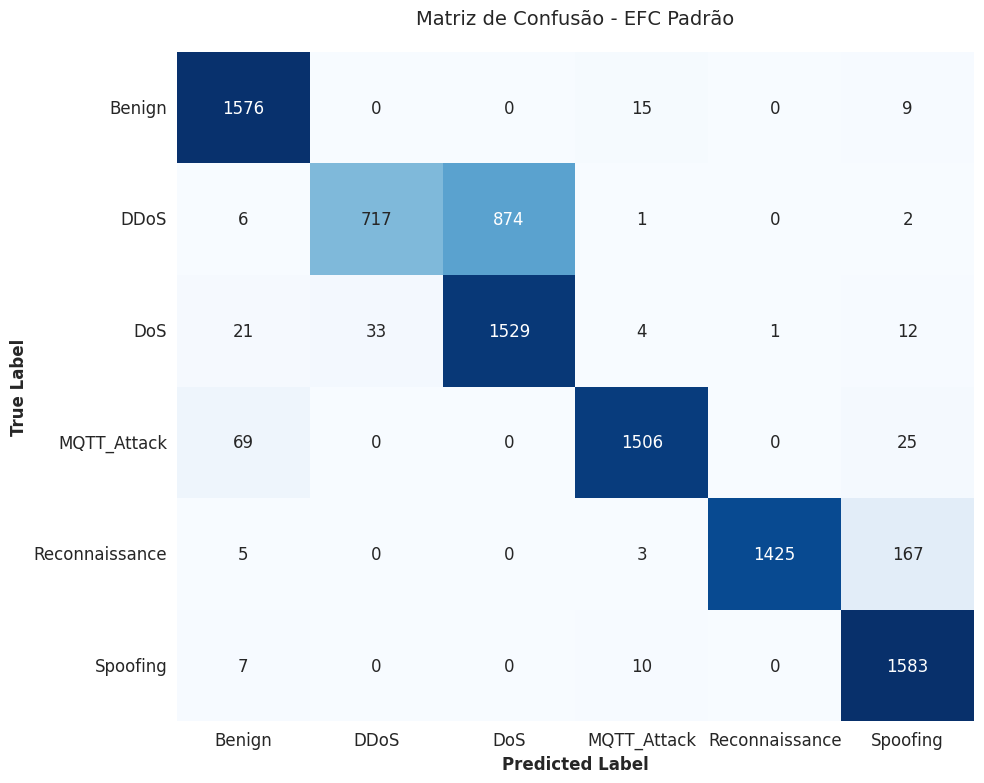

In [ ]:
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

cm = confusion_matrix(y_test_encoded, y_pred)

classes_labels = le.classes_
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes_labels,
            yticklabels = classes_labels,
            cbar = False)

plt.title("Matriz de Confusão - EFC Padrão", fontsize = 14, pad = 20)
plt.ylabel('True Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predicted Label', fontsize = 12, fontweight ='bold')
plt.tight_layout()
plt.show()



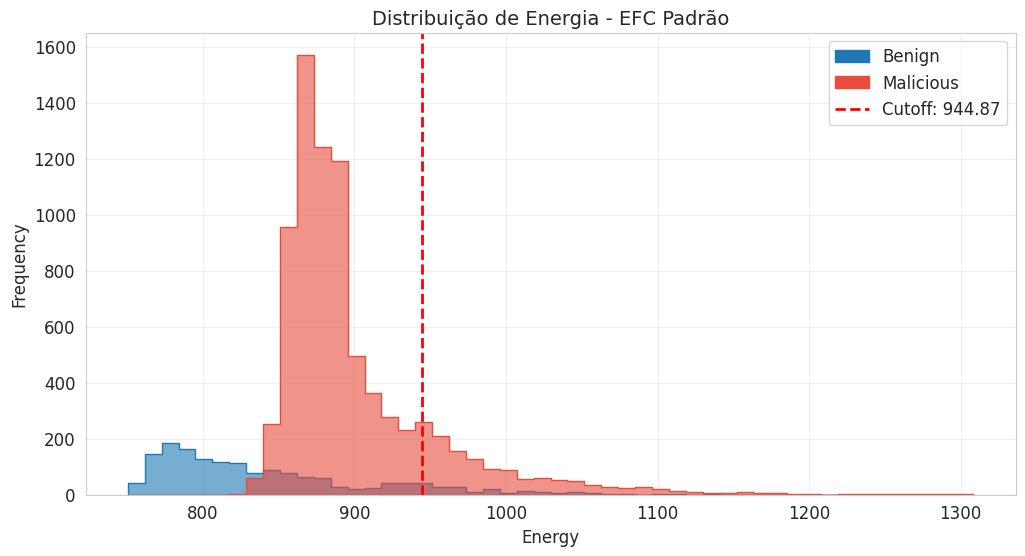

In [ ]:
y_pred, energies = model.predict(X_test, return_energies=True)

df_viz = pd.DataFrame()
df_viz['Energy'] = energies
df_viz['Label'] = le.inverse_transform(y_test_encoded)
df_viz['Tipo'] = df_viz['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')

indice_benigno = le.transform(['Benign'])[0]
cutoff_oficial = model.estimators_[indice_benigno].cutoff_
plt.figure(figsize = (12, 6))
sns.histplot(data = df_viz, x = "Energy", hue = "Tipo",
             element = "step", fill = True, stat = "count",
             bins = 50, alpha = 0.6,
             palette = {"Benign": "#1f77b4", "Malicious": "#E74C3C"},
             legend=False)

plt.axvline(cutoff_oficial, color = 'red', linestyle = '--', linewidth = 2)
legenda_azul = mpatches.Patch(color = "#1f77b4", label = 'Benign')
legenda_vermelho = mpatches.Patch(color = "#E74C3C", label = 'Malicious')

legenda_linha = mlines.Line2D([], [], color = 'red', linestyle = '--', linewidth = 2, label = f'Cutoff: {cutoff_oficial:.2f}')

plt.legend(handles=[legenda_azul, legenda_vermelho, legenda_linha], loc = 'upper right')

plt.title("Distribuição de Energia - EFC Padrão", fontsize = 14)
plt.xlabel("Energy", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

# Randow Forest

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print("\n--- Relatório de Avaliação (RF Padrão) ---\n")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))


--- Relatório de Avaliação (RF Padrão) ---

                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00      1600
          DDoS       0.81      0.78      0.79      1600
           DoS       0.79      0.81      0.80      1600
   MQTT_Attack       0.99      0.99      0.99      1600
Reconnaissance       0.98      0.93      0.95      1600
      Spoofing       0.92      0.97      0.95      1600

      accuracy                           0.91      9600
     macro avg       0.91      0.91      0.91      9600
  weighted avg       0.91      0.91      0.91      9600



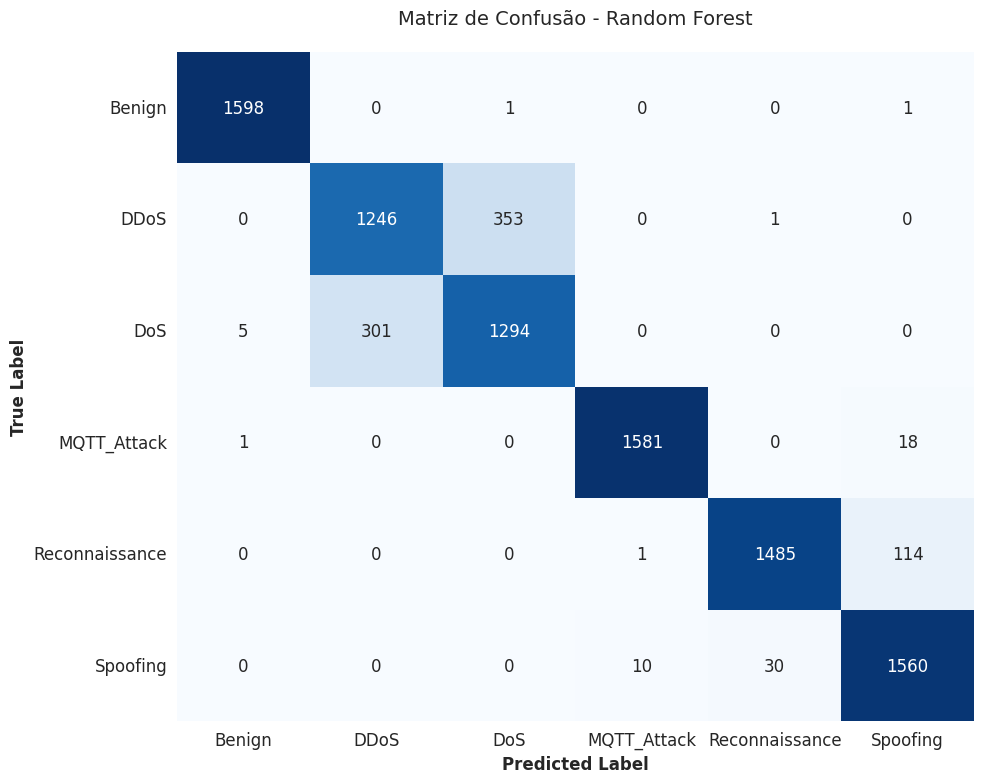

In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred)
classes_labels = le.classes_
plt.figure(figsize = (10, 8))
sns.set_style("white")

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes_labels,
            yticklabels = classes_labels,
            cbar = False)

plt.title("Matriz de Confusão - Random Forest", fontsize = 14, pad = 20)
plt.ylabel('True Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predicted Label', fontsize = 12, fontweight ='bold')
plt.tight_layout()
plt.show()

# Randow FC

Busca pelo melhor Ensemble (de 2 a 10 EFCs)...
-> N = 2: Macro F1 = 0.6958
-> N = 3: Macro F1 = 0.7353
-> N = 4: Macro F1 = 0.8584
-> N = 5: Macro F1 = 0.7380
-> N = 6: Macro F1 = 0.8739
-> N = 7: Macro F1 = 0.7412
-> N = 8: Macro F1 = 0.7389
-> N = 9: Macro F1 = 0.7405
-> N = 10: Macro F1 = 0.7372

Melhor modelo : N = 6 (F1: 0.8739)


--- Relatório Randow FC (N=6) ---

                precision    recall  f1-score   support

        Benign       0.92      0.96      0.94      1600
          DDoS       0.95      0.55      0.70      1600
           DoS       0.68      0.94      0.79      1600
   MQTT_Attack       0.96      0.95      0.96      1600
Reconnaissance       1.00      0.89      0.94      1600
      Spoofing       0.87      0.96      0.91      1600

      accuracy                           0.88      9600
     macro avg       0.90      0.88      0.87      9600
  weighted avg       0.90      0.88      0.87      9600



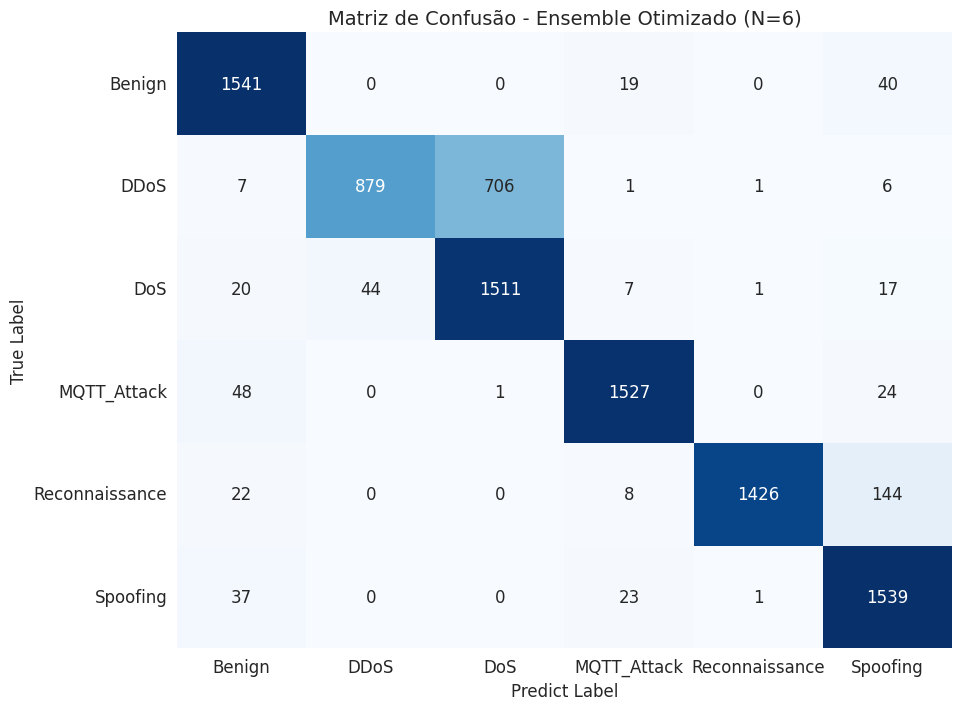

In [ ]:
n_estimators_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
results_macro_f1 = []
best_score = 0
best_model = None
best_n = 0

base_efc_model = EnergyBasedFlowClassifier(
    n_bins=30,
    cutoff_quantile=0.90,
    n_jobs=1
)

ensemble_model = BaggingClassifier(
    estimator = base_efc_model,
    n_estimators = 0,
    warm_start = True,           # Permite adicionar árvores sem retreinar tudo
    max_samples = 0.7,
    max_features = 0.7,
    bootstrap = True,
    bootstrap_features = True,
    n_jobs = 1,
    random_state = 42
)

print(f"Busca pelo melhor Ensemble (de {min(n_estimators_list)} a {max(n_estimators_list)} EFCs)...")

for n_efcs in n_estimators_list:
    ensemble_model.n_estimators = n_efcs

    with parallel_backend('threading'):
        ensemble_model.fit(X_train, y_train_encoded)
        y_pred = ensemble_model.predict(X_test)

    macro_f1 = f1_score(y_test_encoded, y_pred, average = 'macro', zero_division = 0) # Média geral das classes
    results_macro_f1.append(macro_f1)

    print(f"-> N = {n_efcs}: Macro F1 = {macro_f1:.4f}")

    if macro_f1 > best_score:
        best_score = macro_f1
        best_n = n_efcs
        best_model = copy.deepcopy(ensemble_model)

print(f"\nMelhor modelo : N = {best_n} (F1: {best_score:.4f})\n")

# Métricas do melhor modelo
print(f"\n--- Relatório Randow FC (N={best_n}) ---\n")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test_encoded, y_pred_best, target_names=le.classes_))

# Gráfico 2: Matriz de Confusão do Melhor Modelo
cm = confusion_matrix(y_test_encoded, y_pred_best)
plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues',
            xticklabels = le.classes_,
            yticklabels = le.classes_,
            cbar = False)

plt.title(f"Matriz de Confusão - Ensemble Otimizado (N={best_n})", fontsize = 14)
plt.ylabel('True Label', fontsize = 12)
plt.xlabel('Predict Label', fontsize = 12)
plt.show()